# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [31]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1182, 11)


,title,description,date,category,thumbnail,content,author,tags,group,nums_of_comments,url
0,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/bo-suu-tap-trang-suc-dun...
1,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/nhung-thuc-pham-giau-kho...
2,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/5-bai-tap-don-gian-co-th...
3,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/uong-nuoc-cot-chanh-co-g...
4,Mỹ nhân Thái cùng chồng con nghỉ dưỡng ở Nha T...,"Khánh HòaPokchat Thiamchai - sao Thái đóng ""Yê...","Thứ năm, 5/3/2026, 07:00 (GMT+7)",Giới sao,https://i1-giaitri.vnecdn.net/2026/03/04/dien-...,"Trên trang cá nhân ngày 3/3, người đẹp Pokchat...",Như Anh,pokchat thiamchai,Giải trí,0,https://vnexpress.net/my-nhan-thai-cung-chong-...


## 3. Thông tin dữ liệu

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1182 non-null   str  
 1   description       1181 non-null   str  
 2   date              1182 non-null   str  
 3   category          1182 non-null   str  
 4   thumbnail         1098 non-null   str  
 5   content           1182 non-null   str  
 6   author            1182 non-null   str  
 7   tags              1181 non-null   str  
 8   group             1182 non-null   str  
 9   nums_of_comments  1182 non-null   int64
 10  url               1182 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.7 KB


## 4. Kiểm tra dữ liệu thiếu

In [33]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
thumbnail,84,7.106599
description,1,0.084602
tags,1,0.084602
title,0,0.000000
date,0,0.000000
category,0,0.000000
content,0,0.000000
author,0,0.000000
group,0,0.000000
nums_of_comments,0,0.000000


## 5. Xử lý dữ liệu thời gian bị thiếu

## 5. Phân bố dữ liệu ban đầu

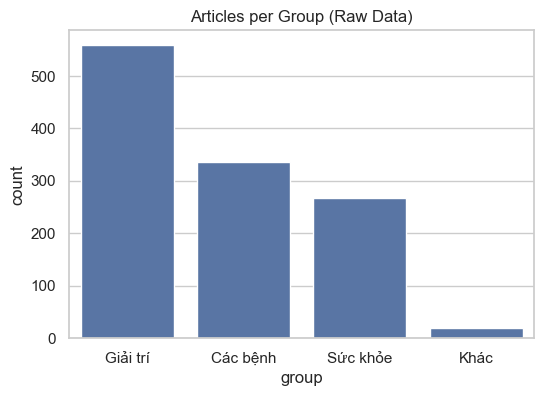

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="group")

plt.title("Articles per Group (Raw Data)")
plt.show()

# 6. Loại bỏ dữ liệu trùng lặp

In [35]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1182
Rows after: 1182


## 7. Loại bỏ bài viết thiếu nội dung

In [36]:
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

Rows after removing missing: 1182


# 8. Làm sạch dữ liệu văn bản

In [37]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [38]:
df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

## 9. Phân tích độ dài văn bản

In [39]:
df["title_length"] = df["title"].apply(lambda x: len(x.split()))
df["content_length"] = df["content"].apply(lambda x: len(x.split()))

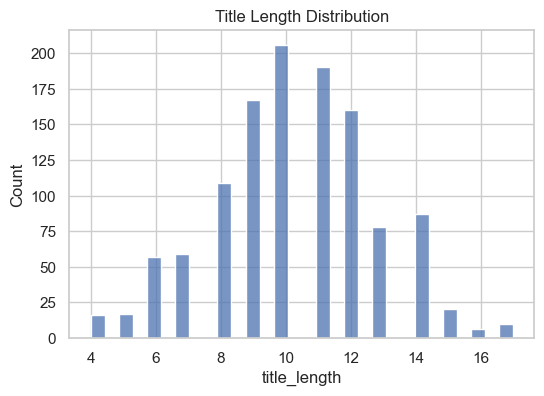

In [40]:
plt.figure(figsize=(6,4))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

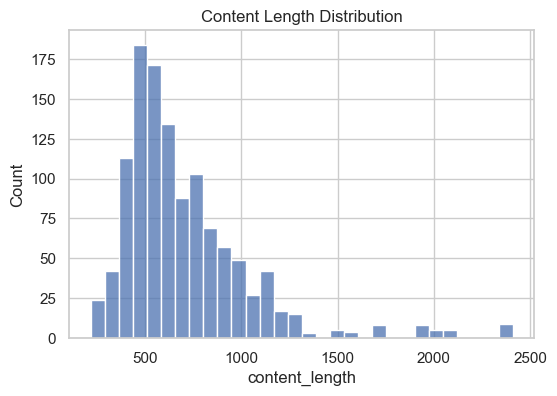

In [41]:
plt.figure(figsize=(6,4))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

# 10. Chuẩn hóa định dạng ngày

In [42]:
def clean_date(text):

    if pd.isna(text):
        return text

    text = re.sub(r'^Thứ.*?,\s*', '', text)

    text = re.sub(r'\(.*?\)', '', text)

    return text.strip()

In [43]:
df["date"] = df["date"].apply(clean_date)

In [44]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y, %H:%M",
    errors="coerce"
)

## 11. Chuẩn hóa group/category

In [45]:


def normalize_category(row):
    group = row["group"]
    category = row["category"]

    # Trường hợp crawler lấy được: Các bệnh > Hô hấp

    # Nếu muốn làm theo hướng gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    # if group == "Các bệnh":
    #     group = "Sức khỏe"
    #     category = "Các bệnh"

    # Nếu muốn giữ nguyên các nhóm riêng biệt, nhưng vẫn gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    if group == "Các bệnh":
        group = "Sức khỏe"

    return pd.Series([group, category])


df[["group", "category"]] = df.apply(normalize_category, axis=1)

# print("Unique groups:", df["group"].unique())
# print("Unique categories:", df["category"].unique())

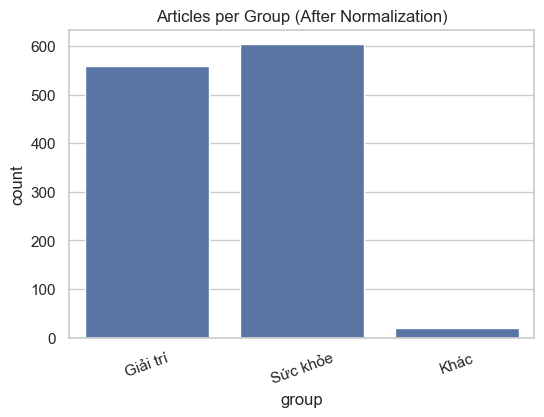

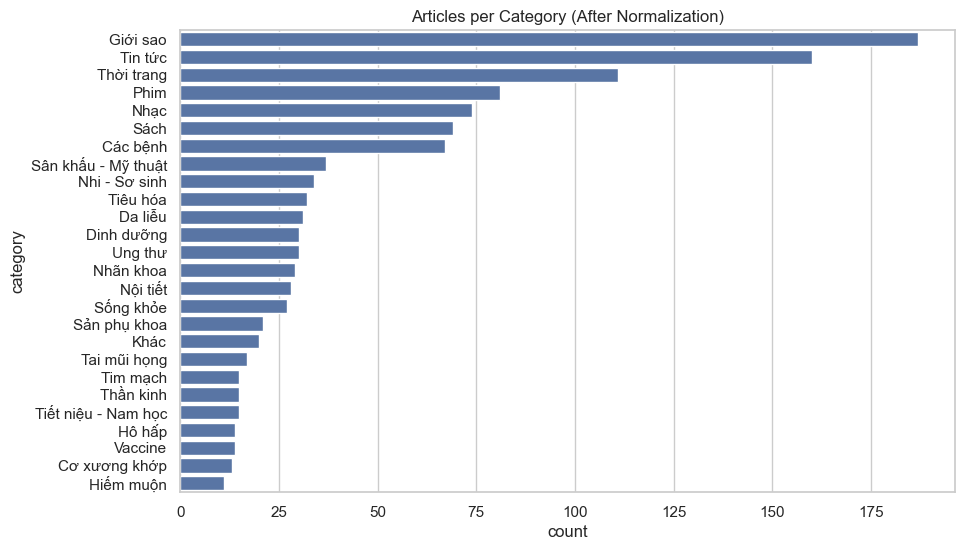

In [46]:
# Visualize group distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="group")
plt.title("Articles per Group (After Normalization)")
plt.xticks(rotation=20)
plt.show()


# Visualize category distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Articles per Category (After Normalization)")

plt.show()

## 12. Tạo feature thời gian

In [47]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

# Giá trị thời gian mặc định
default_date = pd.to_datetime("2026-01-01 07:00:00")

# Điền các giá trị null
df["date"] = df["date"].fillna(default_date)
df["year"] = df["year"].fillna(2026.0)
df["month"] = df["month"].fillna(1.0)
df["hour"] = df["hour"].fillna(7.0)

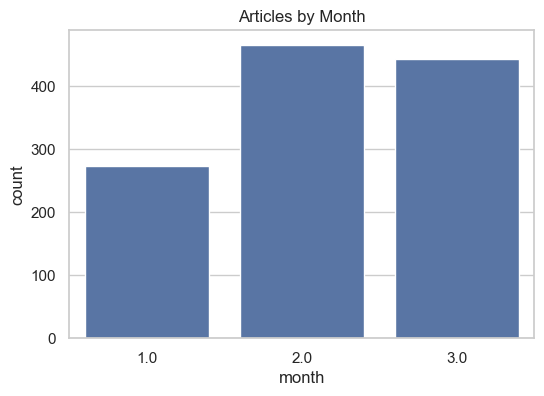

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="month")

plt.title("Articles by Month")

plt.show()

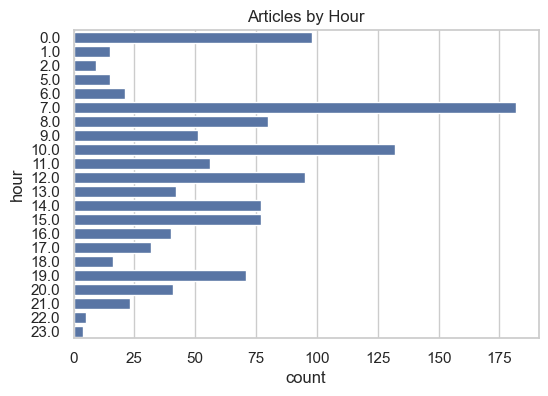

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, y="hour")

plt.title("Articles by Hour")

plt.show()

## 13. Phân tích số lượng bình luận

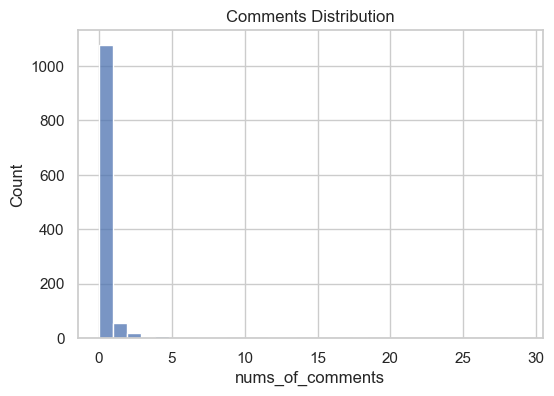

In [50]:
plt.figure(figsize=(6,4))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Comments Distribution")

plt.show()

## 14. Kiểm tra dataset sau khi clean

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1182 non-null   str           
 1   description       1181 non-null   str           
 2   date              1182 non-null   datetime64[us]
 3   category          1182 non-null   str           
 4   thumbnail         1098 non-null   str           
 5   content           1182 non-null   str           
 6   author            1182 non-null   str           
 7   tags              1181 non-null   str           
 8   group             1182 non-null   str           
 9   nums_of_comments  1182 non-null   int64         
 10  url               1182 non-null   str           
 11  title_length      1182 non-null   int64         
 12  content_length    1182 non-null   int64         
 13  year              1182 non-null   float64       
 14  month             1182 non-null   f

In [52]:
df.describe()

,date,nums_of_comments,title_length,content_length,year,month,hour
count,1182,1182.000000,1182.000000,1182.000000,1182.0,1182.000000,1182.000000
mean,2026-02-16 09:27:23.197969,0.351946,10.276650,703.540609,2026.0,2.143824,10.818951
min,2026-01-01 07:00:00,0.000000,4.000000,217.000000,2026.0,1.000000,0.000000
25%,2026-02-03 03:59:15,0.000000,9.000000,478.000000,2026.0,2.000000,7.000000
50%,2026-02-24 12:39:00,0.000000,10.000000,619.000000,2026.0,2.000000,10.000000
75%,2026-03-04 19:26:00,0.000000,12.000000,837.000000,2026.0,3.000000,15.000000
max,2026-03-12 17:46:00,29.000000,17.000000,2412.000000,2026.0,3.000000,23.000000
std,NaN,2.085714,2.449582,339.496499,0.0,0.765221,5.486590


## 15. Lưu dataset đã clean

In [53]:
df.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
